In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")

PROCESSED_PATH = Path("../data/processed")
FIGURES_PATH = Path("../reports/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)


In [2]:
orders = pd.read_csv(PROCESSED_PATH / "orders_enriched.csv", parse_dates=["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date", "purchase_month"])
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_revenue,freight_value,items_count,sellers_count,products_count,payment_value,payment_records,installments_max,payment_types_count,review_score,reviews_count,purchase_month,delivery_days,delay_days,is_late,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,1.00,1.00,1.00,38.71,3.00,1.00,2.00,4.00,1.00,2017-10-01,8.44,-7.11,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,1.00,1.00,1.00,141.46,1.00,1.00,1.00,4.00,1.00,2018-07-01,13.78,-5.36,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,1.00,1.00,1.00,179.12,1.00,3.00,1.00,5.00,1.00,2018-08-01,9.39,-17.25,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,1.00,1.00,1.00,72.20,1.00,1.00,1.00,5.00,1.00,2017-11-01,13.21,-12.98,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,1.00,1.00,1.00,28.62,1.00,1.00,1.00,5.00,1.00,2018-02-01,2.87,-9.24,False,False


In [3]:
orders.shape

(99441, 28)

In [8]:
delivered = orders[(orders["order_status"] == "delivered") & (orders["customer_unique_id"].notna()) & (orders["order_purchase_timestamp"].notna()) & (orders["product_revenue"].notna())].copy()

analysis_date = pd.Timestamp("2018-09-01")
rfm_orders = delivered[delivered["order_purchase_timestamp"] < analysis_date].copy()
print( "Start:", rfm_orders["order_purchase_timestamp"].min())
print("End:", rfm_orders["order_purchase_timestamp"].max())
print("Data of analysis:", analysis_date)

Start: 2016-09-15 12:16:38
End: 2018-08-29 15:00:37
Data of analysis: 2018-09-01 00:00:00


```mermaid
flowchart LR
    A["История заказов клиента"] --> R["Recency<br/>Как давно покупал?"]
    A --> F["Frequency<br/>Сколько раз покупал?"]
    A --> M["Monetary<br/>Сколько потратил?"]
    R --> S["RFM-сегмент"]
    F --> S
    M --> S
```

Recency - количество дней с последней покупки клиента до выбранной даты анализа. Recency Score (r_score) превращает количество дней в оценку от 1 до 4:
| Recency | Интерпретация | R-score |
|---:|---|---:|
| Очень маленький | Покупал совсем недавно | 4 |
| Небольшой | Покупал относительно недавно | 3 |
| Большой | Давно не покупал | 2 |
| Очень большой | Очень давно не покупал | 1 |

Frequency - количество уникальных заказов клиента. F-score отражает повторные покупки. F1 - разовый покупатель, F2 - вернулся один раз, F3 - покупал трижды, F4 - особенно активный клиент

Monetary - общая стоимость товаров, купленных клиентом. Monetary Score: Клиентов сортируем по потраченной сумме и делим на четыре группы.
| Monetary | Интерпретация | M-score |
|---:|---|---:|
| Низкая сумма | Нижние 25% клиентов | 1 |
| Ниже средней | Следующие 25% | 2 |
| Выше средней | Следующие 25% | 3 |
| Высокая сумма | Верхние 25% | 4 |

In [11]:
rfm = rfm_orders.groupby("customer_unique_id", as_index=False).agg(last_purchase=("order_purchase_timestamp", "max"), frequency=("order_id", "nunique"), monetary=("product_revenue", "sum"))
rfm["recency"] = (analysis_date - rfm["last_purchase"]).dt.days
rfm = rfm[["customer_unique_id", "recency", "frequency", "monetary", "last_purchase",]]
rfm.head()

,customer_unique_id,recency,frequency,monetary,last_purchase
0,0000366f3b9a7992bf8c76cfdf3221e2,113,1,129.90,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,116,1,18.90,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,539,1,69.00,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,323,1,25.99,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,290,1,180.00,2017-11-14 19:45:42


In [12]:
rfm[["recency", "frequency", "monetary",]].describe()

,recency,frequency,monetary
count,93358.00,93358.00,93358.00
mean,239.48,1.03,141.62
std,152.60,0.21,215.69
min,2.00,1.00,0.85
25%,116.00,1.00,47.65
50%,220.00,1.00,89.73
75%,348.00,1.00,154.74
max,715.00,15.00,13440.00


In [13]:
rfm["frequency"].value_counts().sort_index().head(10)

frequency
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [17]:
rfm["r_score"] = pd.qcut(rfm["recency"], q=4, labels=[4, 3, 2, 1]).astype(int)
rfm["m_score"] = pd.qcut(rfm["monetary"].rank(method="first"), q=4, labels=[1, 2, 3, 4]).astype(int)

In [18]:
def calculate_frequency_score(frequency):
    if frequency == 1:
        return 1
    elif frequency == 2:
        return 2
    elif frequency == 3:
        return 3
    else:
        return 4

rfm["f_score"] = rfm["frequency"].apply(calculate_frequency_score)

In [20]:
rfm[["r_score", "f_score", "m_score"]].describe()

,r_score,f_score,m_score
count,93358.00,93358.00,93358.00
mean,2.50,1.03,2.50
std,1.12,0.20,1.12
min,1.00,1.00,1.00
25%,2.00,1.00,1.25
50%,3.00,1.00,2.50
75%,4.00,1.00,3.75
max,4.00,4.00,4.00


In [21]:
rfm["f_score"].value_counts().sort_index()

f_score
1    90557
2     2573
3      181
4       47
Name: count, dtype: int64

In [26]:
def assign_segment(row):
    r = row["r_score"]
    f = row["f_score"]
    m = row["m_score"]

    if r >= 3 and f >= 2 and m >= 3:
        return "Champions"

    elif f >= 2 and r >= 2:
        return "Loyal customers"

    elif r == 4 and f == 1:
        return "New customers"

    elif f == 1 and m == 4 and r >= 2:
        return "High-value one-time"

    elif r <= 2 and (f >= 2 or m >= 3):
        return "At risk"

    elif r == 1 and f == 1:
        return "Inactive one-time"

    else:
        return "Regular one-time"


rfm["segment"] = rfm.apply(assign_segment, axis=1)
rfm[[
        "customer_unique_id",
        "recency",
        "frequency",
        "monetary",
        "r_score",
        "f_score",
        "m_score",
        "segment",
]].head()

,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,113,1,129.90,4,1,3,New customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,116,1,18.90,4,1,1,New customers
2,0000f46a3911fa3c0805444483337064,539,1,69.00,1,1,2,Inactive one-time
3,0000f6ccb0745a6a4b88665a16c9f078,323,1,25.99,2,1,1,Regular one-time
4,0004aac84e0df4da2b147fca70cf8255,290,1,180.00,2,1,4,High-value one-time


In [39]:
segment_summary = (rfm.groupby("segment").agg(customers_count=("customer_unique_id", "nunique"), average_recency=("recency","mean"), average_frequency=("frequency","mean"), average_monetary=("monetary","mean"), total_monetary=("monetary","sum"),).reset_index())
segment_summary["customers_share"] = (
    segment_summary["customers_count"]
    / segment_summary["customers_count"].sum()
)
segment_summary = segment_summary.sort_values(
    "customers_count",
    ascending=False
)

segment_summary


,segment,customers_count,average_recency,average_frequency,average_monetary,total_monetary,customers_share
6,Regular one-time,28683,212.78,1.00,61.80,1772615.31,0.31
5,New customers,22760,59.41,1.00,140.16,3190080.33,0.24
0,At risk,17176,396.29,1.04,198.75,3413779.42,0.18
3,Inactive one-time,11750,452.49,1.00,46.64,548068.35,0.13
2,High-value one-time,10765,224.07,1.00,344.61,3709725.36,0.12
1,Champions,1310,114.34,2.16,300.23,393299.50,0.01
4,Loyal customers,914,237.18,2.06,212.18,193929.84,0.01


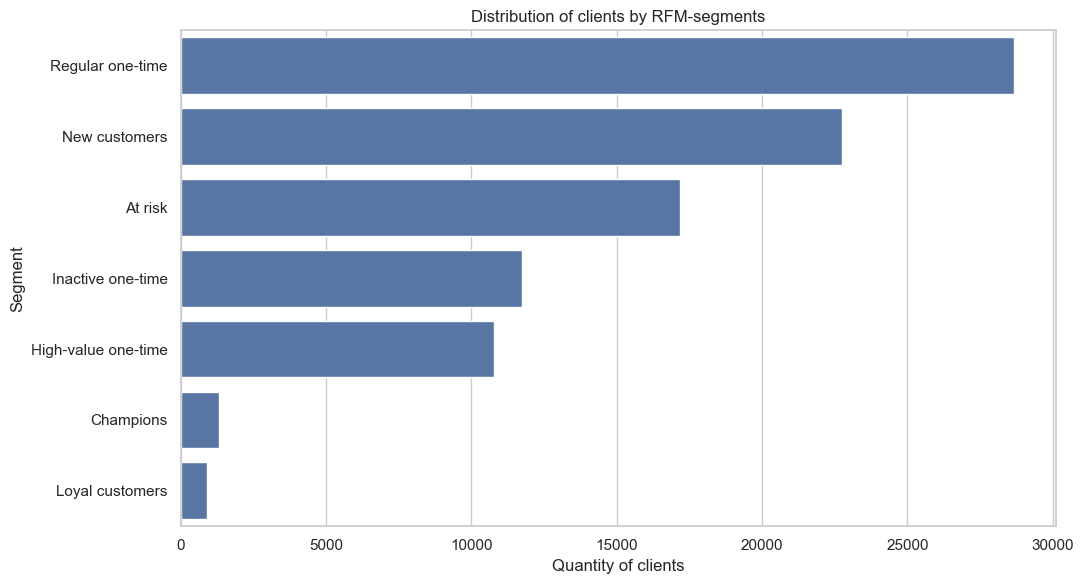

In [40]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=segment_summary,
    x="customers_count",
    y="segment"
)


plt.title("Distribution of clients by RFM-segments")
plt.xlabel("Quantity of clients")
plt.ylabel("Segment")
plt.tight_layout()

In [41]:
plt.savefig(
    FIGURES_PATH / "customer_segments.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

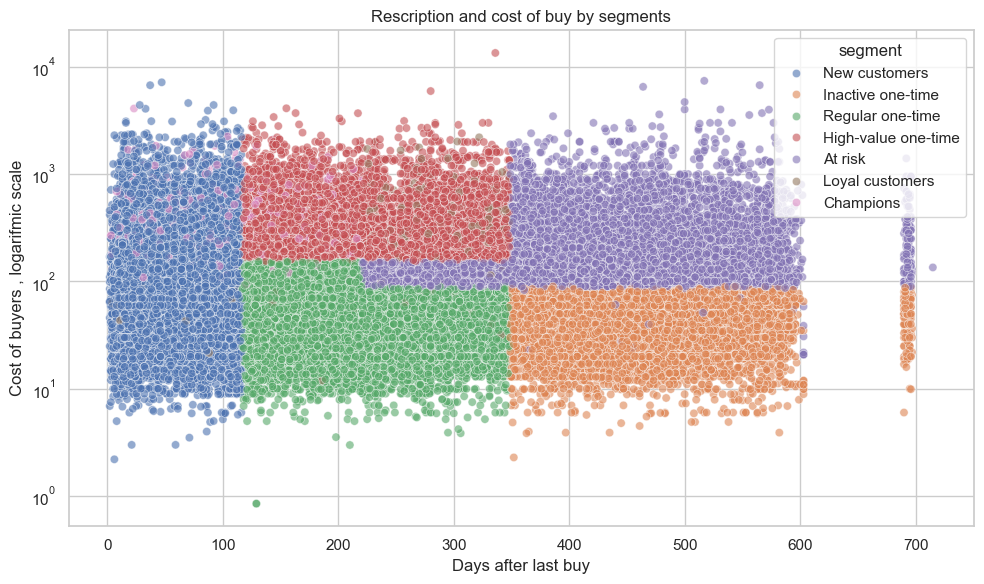

In [45]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="recency",
    y="monetary",
    hue="segment",
    alpha=0.6
)

plt.yscale("log")
plt.title("Rescription and cost of buy by segments")
plt.xlabel("Days after last buy")
plt.ylabel("Cost of buyers , logarifmic scale")
plt.tight_layout()
plt.show()

In [43]:
segment_value = segment_summary[["segment", "customers_count", "customers_share", "average_monetary", "total_monetary"]].sort_values("total_monetary", ascending=False)
segment_value

,segment,customers_count,customers_share,average_monetary,total_monetary
2,High-value one-time,10765,0.12,344.61,3709725.36
0,At risk,17176,0.18,198.75,3413779.42
5,New customers,22760,0.24,140.16,3190080.33
6,Regular one-time,28683,0.31,61.80,1772615.31
3,Inactive one-time,11750,0.13,46.64,548068.35
1,Champions,1310,0.01,300.23,393299.50
4,Loyal customers,914,0.01,212.18,193929.84


In [44]:
rfm.sort_values("monetary", ascending=False).head(10)

,customer_unique_id,recency,frequency,monetary,last_purchase,r_score,m_score,f_score,segment
3724,0a0a92112bd4c708ca5fde585afaa872,336,1,13440.00,2017-09-29 15:24:52,2,4,1,High-value one-time
79636,da122df9eeddfedc1dc1f5349a1a690c,517,2,7388.00,2017-04-01 15:58:41,1,4,2,At risk
43168,763c8b1c9c68a0229c42c9fc6f662b93,47,1,7160.00,2018-07-15 14:49:44,4,4,1,New customers
80463,dc4802a71eae9be1dd28f5d788ceb526,565,1,6735.00,2017-02-12 20:37:36,1,4,1,At risk
25436,459bef486812aa25204be022145caa62,37,1,6729.00,2018-07-25 18:10:17,4,4,1,New customers
93081,ff4159b92c40ebe40454e3e6a7c35ed6,464,1,6499.00,2017-05-24 18:14:34,1,4,1,At risk
23411,4007669dec559734d6f53e029e360987,280,1,5934.60,2017-11-24 11:03:35,2,4,1,High-value one-time
87148,eebb5dda148d3893cdaf5b5ca3040ccb,500,1,4690.00,2017-04-18 18:50:13,1,4,1,At risk
26640,48e1ac109decbb87765a3eade6854098,70,1,4590.00,2018-06-22 12:23:19,4,4,1,New customers
59163,a229eba70ec1c2abef51f04987deb7a5,92,1,4400.00,2018-05-31 22:57:07,4,4,1,New customers


In [46]:
segment_actions = pd.DataFrame({
    "segment": ["Champions", "Loyal customers", "New customers", "High-value one-time", "At risk", "Inactive one-time", "Regular one-time"],
    "recommended_action" : ["Персональные предложения и ранний доступ к акциям", "Программа лояльности и рекомендации товаров", "Стимулирование второй покупки", "Персональное предложение для повторной покупки", "Реактивационная кампания", "Ограниченная реактивация без высоких затрат", "Рекомендации связанных товаров",]
})
segment_actions

,segment,recommended_action
0,Champions,Персональные предложения и ранний доступ к акциям
1,Loyal customers,Программа лояльности и рекомендации товаров
2,New customers,Стимулирование второй покупки
3,High-value one-time,Персональное предложение для повторной покупки
4,At risk,Реактивационная кампания
5,Inactive one-time,Ограниченная реактивация без высоких затрат
6,Regular one-time,Рекомендации связанных товаров


In [47]:
segment_summary = segment_summary.merge(
    segment_actions,
    on="segment",
    how="left",
    validate="one_to_one"
)

segment_summary

,segment,customers_count,average_recency,average_frequency,average_monetary,total_monetary,customers_share,recommended_action
0,Regular one-time,28683,212.78,1.00,61.80,1772615.31,0.31,Рекомендации связанных товаров
1,New customers,22760,59.41,1.00,140.16,3190080.33,0.24,Стимулирование второй покупки
2,At risk,17176,396.29,1.04,198.75,3413779.42,0.18,Реактивационная кампания
3,Inactive one-time,11750,452.49,1.00,46.64,548068.35,0.13,Ограниченная реактивация без высоких затрат
4,High-value one-time,10765,224.07,1.00,344.61,3709725.36,0.12,Персональное предложение для повторной покупки
5,Champions,1310,114.34,2.16,300.23,393299.50,0.01,Персональные предложения и ранний доступ к акциям
6,Loyal customers,914,237.18,2.06,212.18,193929.84,0.01,Программа лояльности и рекомендации товаров


In [51]:
rfm.to_csv(PROCESSED_PATH / "customer_segments.csv", index=False)
assert (rfm["customer_unique_id"].nunique() == len(rfm))
assert rfm["recency"].min() >= 0
assert rfm["r_score"].between(1, 4).all()
assert rfm["f_score"].between(1, 4).all()
assert rfm["m_score"].between(1, 4).all()
assert rfm["monetary"].min() >= 0

In [53]:
segment_summary.to_csv(
    "../data/processed/segment_summary.csv",
    index=False
)

## Выводы четвёртого этапа

1. Для каждого клиента рассчитаны показатели Recency, Frequency и Monetary на дату 1 сентября 2018 года.

2. В анализ вошло **93 358 уникальных клиентов** с завершёнными заказами и известной стоимостью товаров.

3. Большинство клиентов совершило только одну покупку, что согласуется с низким retention, обнаруженным на предыдущем этапе.

4. Наиболее крупным сегментом стал **Regular one-time**, включающий **28 683 клиента**, или **30,72%** выборки. В этот сегмент вошли преимущественно разовые покупатели со средней давностью и стоимостью покупок.

5. Сегмент **Champions** содержит **1 310 клиентов**, или **1,40%** выборки. В среднем они совершили 2,16 заказа, а средняя стоимость покупок составила 300,23.

6. Сегмент **At risk** включает **17 176 клиентов**, или **18,40%** выборки. Эти клиенты отличаются относительно высокой стоимостью или наличием повторных заказов, но давно не совершали покупок: средний Recency сегмента составил 396 дней.

7. Наибольший общий объём стоимости товаров сформировал сегмент **High-value one-time** — **3 709 725,36**. Он включает 10 765 разовых клиентов с высокой средней стоимостью покупки — 344,61.

8. Сегмент **New customers** включает **22 760 клиентов**, или **24,38%** выборки. Для этого сегмента целесообразно стимулировать вторую покупку с помощью персональных рекомендаций и предложений после первого заказа.

9. Для клиентов из сегментов **Champions** и **Loyal customers** можно рассматривать программы лояльности и персональные предложения. Для сегмента **At risk** — реактивационные кампании, а для разовых клиентов — рекомендации связанных товаров.

10. Сегментация основана на исторических транзакциях и не доказывает, что предложенные действия приведут к увеличению повторных покупок. Эффективность рекомендаций необходимо проверять с помощью контролируемых экспериментов.

11. На следующем этапе будет проведён статистический анализ факторов, связанных с оценками клиентов и сроками доставки.